In [18]:
import os
import tarfile
import pickle
import requests
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers

In [16]:
# --------------------------------------------------
# Download CIFAR-10 to Assignment 2 folder
# --------------------------------------------------

import os
import requests

# Dataset folder
dataset_dir = r"D:\Deep Learning\Assignment 2"
os.makedirs(dataset_dir, exist_ok=True)

# CIFAR-10 URL
url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

# Save location
archive_path = os.path.join(
    dataset_dir,
    "cifar-10-python.tar.gz"
)

print("Downloading CIFAR-10 dataset...")
print("Save location:", archive_path)

response = requests.get(url, stream=True, timeout=60)
response.raise_for_status()

with open(archive_path, "wb") as file:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            file.write(chunk)

print("Download completed successfully!")
print("Dataset saved at:", archive_path)

Save location: D:\Deep Learning\Assignment 2\cifar-10-python.tar.gz
Download completed successfully!
Dataset saved at: D:\Deep Learning\Assignment 2\cifar-10-python.tar.gz


In [19]:
# --------------------------------------------------
# 3. Extract CIFAR-10 dataset
# --------------------------------------------------

if not os.path.exists(extract_dir):

    print("Extracting CIFAR-10 dataset...")

    with tarfile.open(
        archive_path,
        "r:gz"
    ) as tar:

        tar.extractall(dataset_dir)

    print("Extraction completed.")

else:
    print("CIFAR-10 dataset is already extracted.")

print("Dataset location:", extract_dir)

Extracting CIFAR-10 dataset...


C:\Users\bodkh\AppData\Local\Temp\ipykernel_22316\2538800136.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


Extraction completed.
Dataset location: D:\Deep Learning\Assignment 2\cifar-10-batches-py


In [20]:
# --------------------------------------------------
# 4. Load CIFAR-10 dataset
# --------------------------------------------------

def load_batch(file_path):

    with open(file_path, "rb") as file:
        data = pickle.load(
            file,
            encoding="bytes"
        )

    images = data[b"data"]
    labels = data[b"labels"]

    # Convert from:
    # (10000, 3072)
    #
    # to:
    # (10000, 32, 32, 3)

    images = images.reshape(
        -1,
        3,
        32,
        32
    )

    images = images.transpose(
        0,
        2,
        3,
        1
    )

    return images, np.array(labels)


# --------------------------------------------------
# Load training data
# --------------------------------------------------

train_images_list = []
train_labels_list = []

for i in range(1, 6):

    file_path = os.path.join(
        extract_dir,
        f"data_batch_{i}"
    )

    images, labels = load_batch(file_path)

    train_images_list.append(images)
    train_labels_list.append(labels)


train_images = np.concatenate(
    train_images_list,
    axis=0
)

train_labels = np.concatenate(
    train_labels_list,
    axis=0
)


# --------------------------------------------------
# Load testing data
# --------------------------------------------------

test_file = os.path.join(
    extract_dir,
    "test_batch"
)

test_images, test_labels = load_batch(
    test_file
)


# Match TensorFlow CIFAR-10 label shape
train_labels = train_labels.reshape(-1, 1)
test_labels = test_labels.reshape(-1, 1)


# --------------------------------------------------
# Display shapes
# --------------------------------------------------

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)

print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [21]:
# --------------------------------------------------
# 5. Normalize images
# --------------------------------------------------

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Normalization completed.")

print(
    "Training pixel range:",
    train_images.min(),
    "to",
    train_images.max()
)

print(
    "Testing pixel range:",
    test_images.min(),
    "to",
    test_images.max()
)

Normalization completed.
Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


In [22]:
# --------------------------------------------------
# 6. CIFAR-10 class names
# --------------------------------------------------

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


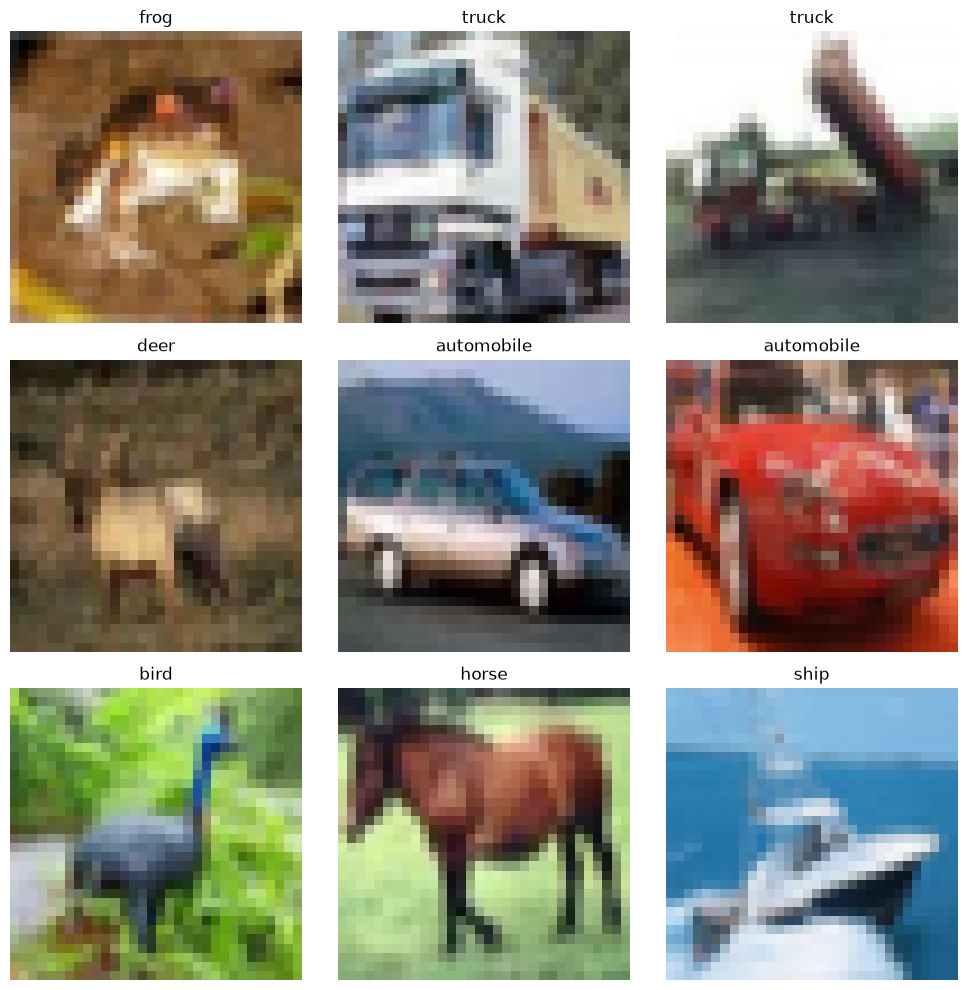

In [23]:
# --------------------------------------------------
# 7. Display sample CIFAR-10 images
# --------------------------------------------------

plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(train_images[i])

    label = train_labels[i][0]

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
# --------------------------------------------------
# Create + Compile MLP Model
# --------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers

# Create model
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

print("========================================")
print("MODEL CREATED AND COMPILED SUCCESSFULLY")
print("========================================")

model.summary()

MODEL CREATED AND COMPILED SUCCESSFULLY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# --------------------------------------------------
# 11. Evaluate model
# --------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print("\nCIFAR-10 Test Loss:", test_loss)
print("CIFAR-10 Test Accuracy:", test_accuracy)
print("CIFAR-10 Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1060 - loss: 2.3225

CIFAR-10 Test Loss: 2.3224902153015137
CIFAR-10 Test Accuracy: 0.10599999874830246
CIFAR-10 Test Accuracy (%): 10.599999874830246


In [33]:
# --------------------------------------------------
# 12. Save model
# --------------------------------------------------

model_path = os.path.join(
    dataset_dir,
    "cifar10_mlp_model.keras"
)

model.save(model_path)

print("\nCIFAR-10 model saved successfully!")
print("Model location:", model_path)


CIFAR-10 model saved successfully!
Model location: D:\Deep Learning\Assignment 2\cifar10_mlp_model.keras


In [36]:
# --------------------------------------------------
# Train MLP Model
# --------------------------------------------------

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_images, test_labels),
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3063 - loss: 1.9095 - val_accuracy: 0.3631 - val_loss: 1.7609
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3885 - loss: 1.7041 - val_accuracy: 0.3999 - val_loss: 1.6660
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4222 - loss: 1.6097 - val_accuracy: 0.4411 - val_loss: 1.5630
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4472 - loss: 1.5494 - val_accuracy: 0.4505 - val_loss: 1.5294
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4624 - loss: 1.5035 - val_accuracy: 0.4509 - val_loss: 1.5611
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4775 - loss: 1.4604 - val_accuracy: 0.4751 - val_loss: 1.4822
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.4910 - loss: 1.4259 - val_accuracy: 0.4687 - val_loss: 1.4883
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4966 - loss: 1.4059 - val_

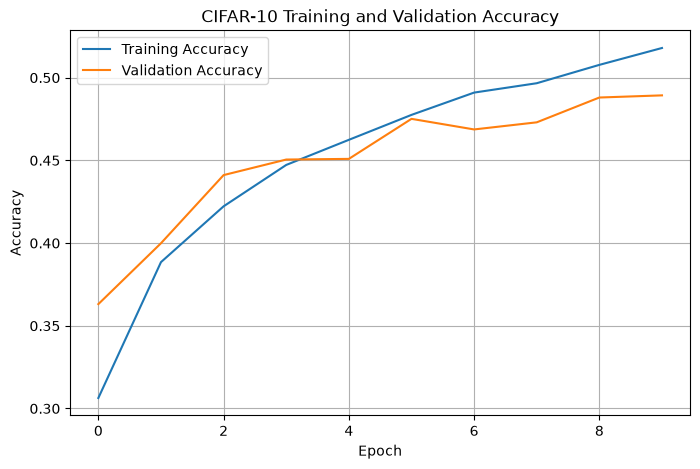

In [37]:
# --------------------------------------------------
# Plot training and validation accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CIFAR-10 Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [38]:
# --------------------------------------------------
# 17. Make predictions
# --------------------------------------------------

predictions = model.predict(test_images)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = test_labels.flatten()

print("Predicted classes:")
print(predicted_classes[:20])

print("\nActual classes:")
print(actual_classes[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted classes:
[3 9 1 0 4 6 1 6 2 1 8 9 5 0 1 8 5 7 8 7]

Actual classes:
[3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


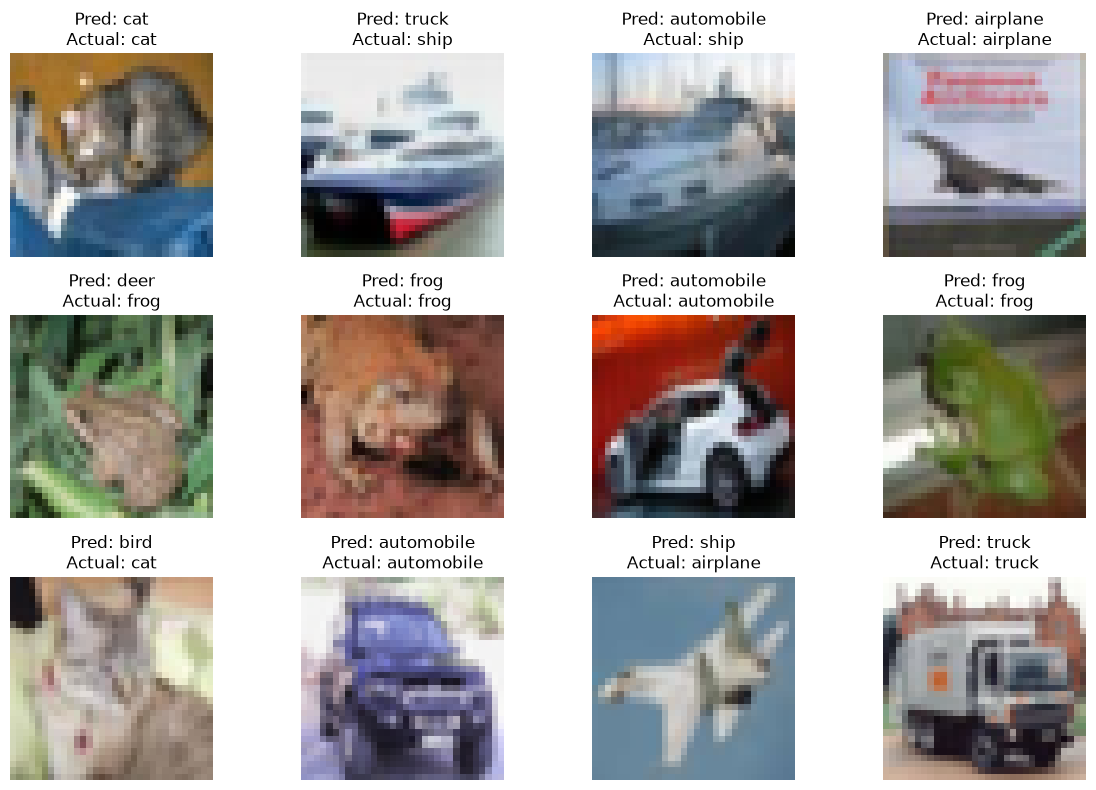

In [39]:
# --------------------------------------------------
# 18. Display sample predictions
# --------------------------------------------------

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[i])

    predicted_label = class_names[
        predicted_classes[i]
    ]

    actual_label = class_names[
        actual_classes[i]
    ]

    plt.title(
        f"Pred: {predicted_label}\nActual: {actual_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
# --------------------------------------------------
# 19. Calculate prediction accuracy
# --------------------------------------------------

correct_predictions = np.sum(
    predicted_classes == actual_classes
)

total_predictions = len(actual_classes)

prediction_accuracy = (
    correct_predictions / total_predictions
)

print("========================================")
print("PREDICTION RESULTS")
print("========================================")

print("Correct Predictions:", correct_predictions)
print("Total Predictions:", total_predictions)

print(
    "Prediction Accuracy:",
    prediction_accuracy * 100,
    "%"
)

PREDICTION RESULTS
Correct Predictions: 4893
Total Predictions: 10000
Prediction Accuracy: 48.93 %


In [41]:
# --------------------------------------------------
# 20. Final CIFAR-10 MLP Results
# --------------------------------------------------

print("\n========================================")
print("       CIFAR-10 MLP FINAL RESULTS")
print("========================================")

print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Accuracy (%)    : {test_accuracy * 100:.2f}%")

print("\nModel:")
print("MLP (Multi-Layer Perceptron)")

print("\nHidden Layers:")
print("512 → 256 → 128 → 64")

print("\nOutput Classes:")
print("10")

print("\nEpochs:")
print("10")

print("\nBatch Size:")
print("128")

print("\nOptimizer:")
print("Adam")

print("\nModel Location:")
print(model_path)

print("========================================")


       CIFAR-10 MLP FINAL RESULTS
Test Loss       : 2.3225
Test Accuracy   : 0.1060
Accuracy (%)    : 10.60%

Model:
MLP (Multi-Layer Perceptron)

Hidden Layers:
512 → 256 → 128 → 64

Output Classes:
10

Epochs:
10

Batch Size:
128

Optimizer:
Adam

Model Location:
D:\Deep Learning\Assignment 2\cifar10_mlp_model.keras
